In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [9]:
data_path = "../data/processed/stock_model_dataset.csv"

df = pd.read_csv(data_path)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

print("Shape:", df.shape)
print("Stocks:", df["Ticker"].nunique())
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

Shape: (275531, 85)
Stocks: 49
Start: 1999-04-08 00:00:00+05:30
End: 2026-01-30 00:00:00+05:30


In [10]:
print(df.head())
print()
print(df.dtypes.value_counts())
print()
print("Missing values:", df.isnull().sum().sum())

                       Date        Ticker  Return_1D  Return_5D  Return_10D  \
0 1999-04-08 00:00:00+05:30   AXISBANK.NS  -0.007547  -0.057347   -0.060714   
1 1999-04-08 00:00:00+05:30       BPCL.NS   0.033241  -0.013228   -0.076732   
2 1999-04-08 00:00:00+05:30  BRITANNIA.NS  -0.074859  -0.124331    0.015504   
3 1999-04-08 00:00:00+05:30      CIPLA.NS   0.034216   0.074107   -0.000631   
4 1999-04-08 00:00:00+05:30    DRREDDY.NS  -0.021803  -0.113797   -0.114841   

   Return_20D      SMA_5     SMA_10     SMA_20  SMA_50_new  ...  \
0   -0.123333   1.765659   1.777580   1.826258    1.948053  ...   
1   -0.074212   2.399315   2.472905   2.531582    2.564678  ...   
2    0.111111  66.497278  65.171128  61.762002   57.178887  ...   
3    0.022959  31.424294  31.374074  30.799417   28.051405  ...   
4   -0.049456  33.793614  35.237476  35.063043   30.204978  ...   

   MACD_Above_Zero  BB_Position  Volatility_Ratio  High_Volatility  \
0                0     0.168604          1.005679   

In [11]:
feature_list_path = "../data/processed/feature_list.csv"

feature_columns = pd.read_csv(
    feature_list_path
)["Feature"].tolist()

print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 82
['Return_1D', 'Return_5D', 'Return_10D', 'Return_20D', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50_new', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Diff', 'BB_Middle', 'BB_High', 'BB_Low', 'BB_Width', 'ATR_14', 'Volume_SMA_20', 'Volume_Ratio', 'Volatility_5D', 'Volatility_10D', 'Volatility_20D_new', 'Price_vs_SMA20', 'Price_vs_SMA50', 'EMA12_vs_EMA26', 'High_Low_Range', 'Open_Close_Range', 'Upper_Shadow', 'Lower_Shadow', 'ROC_10', 'ROC_20', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Momentum_5D', 'Momentum_10D', 'Momentum_20D', 'Momentum_5D_pct', 'Momentum_10D_pct', 'Momentum_20D_pct', 'Distance_52W_High', 'Distance_52W_Low', '52W_Range_Position', 'Body_Size', 'Candle_Direction', 'Range_Position', 'Volume_Change_1D', 'Volume_Change_5D', 'Volume_SMA_5', 'Volume_SMA_10', 'Volume_Ratio_5D', 'Volume_Ratio_10D', 'Rolling_High_5D', 'Rolling_Low_5D', 'Rolling_High_20D', 'Rolling_Low_20D', 'Distance_Rolling_High

In [12]:
print("Target in features:", "Target" in feature_columns)
print("Next_Close in features:", "Next_Close" in feature_columns)

future_features = [
    col for col in feature_columns
    if "Next" in col or "Future" in col
]

print("Future features:", future_features)

Target in features: False
Next_Close in features: False
Future features: []


In [13]:
X = df[feature_columns].copy()

y = df["Target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (275531, 82)
y shape: (275531,)


In [14]:
unique_dates = np.sort(
    df["Date"].unique()
)

print("Trading dates:", len(unique_dates))
print("First date:", unique_dates[0])
print("Last date:", unique_dates[-1])

Trading dates: 6519
First date: 1999-04-08 00:00:00+05:30
Last date: 2026-01-30 00:00:00+05:30


In [15]:
n_dates = len(unique_dates)

train_end_index = int(n_dates * 0.70)
validation_end_index = int(n_dates * 0.85)

train_end_date = unique_dates[
    train_end_index - 1
]

validation_end_date = unique_dates[
    validation_end_index - 1
]

print("Training ends:", train_end_date)
print("Validation ends:", validation_end_date)

Training ends: 2018-02-23 00:00:00+05:30
Validation ends: 2022-02-10 00:00:00+05:30


In [16]:
train_mask = (
    df["Date"] <= train_end_date
)

validation_mask = (
    (df["Date"] > train_end_date) &
    (df["Date"] <= validation_end_date)
)

test_mask = (
    df["Date"] > validation_end_date
)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_validation = X.loc[validation_mask]
y_validation = y.loc[validation_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

Training: (179870, 82)
Validation: (47909, 82)
Test: (47752, 82)


In [17]:
print("TRAIN")
print(
    df.loc[train_mask, "Date"].min(),
    "→",
    df.loc[train_mask, "Date"].max()
)

print()

print("VALIDATION")
print(
    df.loc[validation_mask, "Date"].min(),
    "→",
    df.loc[validation_mask, "Date"].max()
)

print()

print("TEST")
print(
    df.loc[test_mask, "Date"].min(),
    "→",
    df.loc[test_mask, "Date"].max()
)

TRAIN
1999-04-08 00:00:00+05:30 → 2018-02-23 00:00:00+05:30

VALIDATION
2018-02-26 00:00:00+05:30 → 2022-02-10 00:00:00+05:30

TEST
2022-02-11 00:00:00+05:30 → 2026-01-30 00:00:00+05:30


In [18]:
print("Training target:")
print(y_train.value_counts(normalize=True))

print()

print("Validation target:")
print(y_validation.value_counts(normalize=True))

print()

print("Test target:")
print(y_test.value_counts(normalize=True))

Training target:
Target
0    0.500272
1    0.499728
Name: proportion, dtype: float64

Validation target:
Target
1    0.510447
0    0.489553
Name: proportion, dtype: float64

Test target:
Target
1    0.511036
0    0.488964
Name: proportion, dtype: float64


In [19]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(
    X_train,
    y_train
)

baseline_predictions = baseline.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline Accuracy:",
    round(baseline_accuracy * 100, 2),
    "%"
)

Baseline Accuracy: 48.9 %


In [20]:
def evaluate_model(model, X_data, y_data):
    predictions = model.predict(X_data)

    accuracy = accuracy_score(
        y_data,
        predictions
    )

    precision = precision_score(
        y_data,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_data,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_data,
        predictions,
        zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)

In [22]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_validation_results = evaluate_model(
    logistic_model,
    X_validation_scaled,
    y_validation
)

print(logistic_validation_results)

{'Accuracy': 0.5050408065290446, 'Precision': 0.5120517151767152, 'Recall': 0.6445716622367614, 'F1': 0.5707199623454443}


In [23]:
logistic_test_results = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test
)

print(logistic_test_results)

{'Accuracy': 0.5084184955603954, 'Precision': 0.5132915557844736, 'Recall': 0.7350735565299349, 'F1': 0.6044818871103622}


In [24]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_validation_results = evaluate_model(
    rf_model,
    X_validation,
    y_validation
)

print(rf_validation_results)

{'Accuracy': 0.5103842701788808, 'Precision': 0.516744966442953, 'Recall': 0.6296871805356777, 'F1': 0.5676527508985347}


In [25]:
rf_test_results = evaluate_model(
    rf_model,
    X_test,
    y_test
)

print(rf_test_results)

{'Accuracy': 0.5080834310604792, 'Precision': 0.5160552878697289, 'Recall': 0.6012785313281154, 'F1': 0.5554167612991142}


In [26]:
from xgboost import XGBClassifier

In [27]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_validation_results = evaluate_model(
    xgb_model,
    X_validation,
    y_validation
)

print(xgb_validation_results)

{'Accuracy': 0.5091527687908326, 'Precision': 0.5213535270841861, 'Recall': 0.4687384992843999, 'F1': 0.4936479910425908}


In [28]:
xgb_test_results = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

print(xgb_test_results)

{'Accuracy': 0.5069944714357514, 'Precision': 0.5180859555518212, 'Recall': 0.5053477031512519, 'F1': 0.5116375554910177}


In [29]:
results = pd.DataFrame([
    {
        "Model": "Baseline",
        **evaluate_model(
            baseline,
            X_test,
            y_test
        )
    },
    {
        "Model": "Logistic Regression",
        **logistic_test_results
    },
    {
        "Model": "Random Forest",
        **rf_test_results
    },
    {
        "Model": "XGBoost",
        **xgb_test_results
    }
])

results = results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.508418,0.513292,0.735074,0.604482
1,Random Forest,0.508083,0.516055,0.601279,0.555417
2,XGBoost,0.506994,0.518086,0.505348,0.511638
3,Baseline,0.488964,0.000000,0.000000,0.000000


In [30]:
best_model_name = results.iloc[0]["Model"]

print(
    "Best model by test accuracy:",
    best_model_name
)

Best model by test accuracy: Logistic Regression


In [31]:
xgb_predictions = xgb_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    xgb_predictions
)

print(cm)

[[11878 11471]
 [12071 12332]]


In [32]:
print(
    classification_report(
        y_test,
        xgb_predictions,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        DOWN       0.50      0.51      0.50     23349
          UP       0.52      0.51      0.51     24403

    accuracy                           0.51     47752
   macro avg       0.51      0.51      0.51     47752
weighted avg       0.51      0.51      0.51     47752



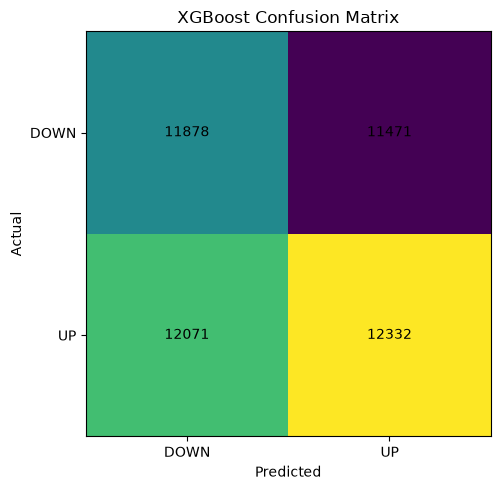

In [33]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["DOWN", "UP"]
)

plt.yticks(
    [0, 1],
    ["DOWN", "UP"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [34]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

                      Feature  Importance
78         Trend_Strength_20D    0.015540
65             RSI_Overbought    0.015385
33                Close_Lag_1    0.015305
14                  BB_Middle    0.014354
46           Distance_52W_Low    0.014242
16                     BB_Low    0.013980
42            Momentum_5D_pct    0.013708
60            Rolling_Low_20D    0.013682
31                     ROC_10    0.013593
49           Candle_Direction    0.013538
36               Return_Lag_1    0.013532
1                   Return_5D    0.013486
26             EMA12_vs_EMA26    0.013446
57            Rolling_High_5D    0.013441
63  Distance_Rolling_High_20D    0.013395
0                   Return_1D    0.013355
41               Momentum_20D    0.013190
9                      EMA_26    0.013092
35                Close_Lag_3    0.013060
25             Price_vs_SMA50    0.012996


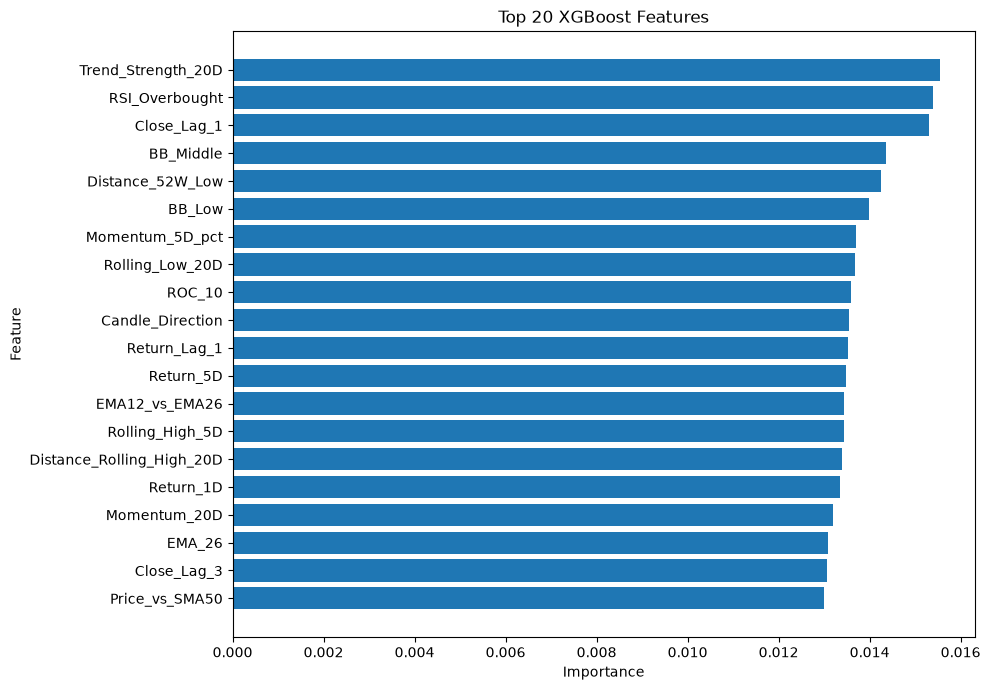

In [35]:
top_features = importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

In [36]:
importance.to_csv(
    "../data/processed/xgboost_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [37]:
test_predictions = df.loc[
    test_mask,
    ["Date", "Ticker", "Target"]
].copy()

test_predictions["Prediction"] = (
    xgb_predictions
)

test_predictions.to_csv(
    "../data/processed/xgboost_test_predictions.csv",
    index=False
)

print(test_predictions.head())

                            Date         Ticker  Target  Prediction
227779 2022-02-11 00:00:00+05:30    ADANIENT.NS       0           0
227780 2022-02-11 00:00:00+05:30  ADANIPORTS.NS       0           1
227781 2022-02-11 00:00:00+05:30  APOLLOHOSP.NS       0           1
227782 2022-02-11 00:00:00+05:30  ASIANPAINT.NS       0           1
227783 2022-02-11 00:00:00+05:30    AXISBANK.NS       0           0


In [38]:
print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

Training: (179870, 82)
Validation: (47909, 82)
Test: (47752, 82)


In [39]:
print("Training dates:", df.loc[train_mask, "Date"].min(), "→", df.loc[train_mask, "Date"].max())
print("Validation dates:", df.loc[validation_mask, "Date"].min(), "→", df.loc[validation_mask, "Date"].max())
print("Test dates:", df.loc[test_mask, "Date"].min(), "→", df.loc[test_mask, "Date"].max())

Training dates: 1999-04-08 00:00:00+05:30 → 2018-02-23 00:00:00+05:30
Validation dates: 2018-02-26 00:00:00+05:30 → 2022-02-10 00:00:00+05:30
Test dates: 2022-02-11 00:00:00+05:30 → 2026-01-30 00:00:00+05:30


In [40]:
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.508418,0.513292,0.735074,0.604482
1,Random Forest,0.508083,0.516055,0.601279,0.555417
2,XGBoost,0.506994,0.518086,0.505348,0.511638
3,Baseline,0.488964,0.000000,0.000000,0.000000


In [41]:
print("Logistic Regression")
print(logistic_validation_results)

print("\nRandom Forest")
print(rf_validation_results)

print("\nXGBoost")
print(xgb_validation_results)

Logistic Regression
{'Accuracy': 0.5050408065290446, 'Precision': 0.5120517151767152, 'Recall': 0.6445716622367614, 'F1': 0.5707199623454443}

Random Forest
{'Accuracy': 0.5103842701788808, 'Precision': 0.516744966442953, 'Recall': 0.6296871805356777, 'F1': 0.5676527508985347}

XGBoost
{'Accuracy': 0.5091527687908326, 'Precision': 0.5213535270841861, 'Recall': 0.4687384992843999, 'F1': 0.4936479910425908}


In [42]:
test_results = df.loc[
    test_mask,
    ["Date", "Ticker", "Target"]
].copy()

test_results["Prediction"] = xgb_predictions

test_results["Year"] = (
    test_results["Date"].dt.year
)

yearly_accuracy = (
    test_results
    .groupby("Year")
    .apply(
        lambda x: accuracy_score(
            x["Target"],
            x["Prediction"]
        )
    )
)

print(yearly_accuracy)

Year
2022    0.510360
2023    0.508955
2024    0.502324
2025    0.508711
2026    0.479592
dtype: float64


In [43]:
xgb_probabilities = xgb_model.predict_proba(
    X_test
)[:, 1]

print(xgb_probabilities[:20])

[0.44456425 0.5151559  0.5012555  0.5050818  0.3889385  0.4963994
 0.48502335 0.5027472  0.4803563  0.4901678  0.5496002  0.4678433
 0.4972998  0.54346055 0.58040994 0.5504996  0.4762184  0.49479488
 0.47949073 0.6206786 ]


In [44]:
print(
    pd.Series(
        xgb_probabilities
    ).describe()
)

count    47752.000000
mean         0.498495
std          0.053552
min          0.138608
25%          0.468934
50%          0.499832
75%          0.530942
max          0.757217
dtype: float64


In [45]:
xgb_validation_probabilities = (
    xgb_model.predict_proba(
        X_validation
    )[:, 1]
)

In [46]:
threshold_results = []

for threshold in np.arange(
    0.30,
    0.71,
    0.01
):
    predictions = (
        xgb_validation_probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_validation,
        predictions
    )

    f1 = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "F1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print(
    threshold_df.sort_values(
        "Accuracy",
        ascending=False
    ).head(10)
)

    Threshold  Accuracy        F1
17       0.47  0.513954  0.607385
16       0.46  0.513787  0.625847
18       0.48  0.513265  0.580299
12       0.42  0.512910  0.659617
15       0.45  0.512889  0.638315
13       0.43  0.512764  0.654418
14       0.44  0.512743  0.647446
10       0.40  0.512430  0.665818
11       0.41  0.512367  0.662857
9        0.39  0.512075  0.667766


In [47]:
best_threshold_row = (
    threshold_df
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .iloc[0]
)

best_threshold = (
    best_threshold_row["Threshold"]
)

print(
    "Best validation threshold:",
    best_threshold
)

print(
    "Validation accuracy:",
    best_threshold_row["Accuracy"]
)

print(
    "Validation F1:",
    best_threshold_row["F1"]
)

Best validation threshold: 0.47000000000000014
Validation accuracy: 0.5139535369137322
Validation F1: 0.6073849266565503


In [48]:
xgb_test_threshold_predictions = (
    xgb_probabilities >= best_threshold
).astype(int)

threshold_test_accuracy = accuracy_score(
    y_test,
    xgb_test_threshold_predictions
)

threshold_test_precision = precision_score(
    y_test,
    xgb_test_threshold_predictions,
    zero_division=0
)

threshold_test_recall = recall_score(
    y_test,
    xgb_test_threshold_predictions,
    zero_division=0
)

threshold_test_f1 = f1_score(
    y_test,
    xgb_test_threshold_predictions,
    zero_division=0
)

print(
    "Test Accuracy:",
    round(threshold_test_accuracy * 100, 2),
    "%"
)

print(
    "Test Precision:",
    round(threshold_test_precision * 100, 2),
    "%"
)

print(
    "Test Recall:",
    round(threshold_test_recall * 100, 2),
    "%"
)

print(
    "Test F1:",
    round(threshold_test_f1 * 100, 2),
    "%"
)

Test Accuracy: 51.2 %
Test Precision: 51.55 %
Test Recall: 74.91 %
Test F1: 61.08 %


In [49]:
threshold_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Default_0.50": [
        accuracy_score(
            y_test,
            xgb_predictions
        ),
        precision_score(
            y_test,
            xgb_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            xgb_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            xgb_predictions,
            zero_division=0
        )
    ],
    "Validation_Optimal": [
        threshold_test_accuracy,
        threshold_test_precision,
        threshold_test_recall,
        threshold_test_f1
    ]
})

threshold_comparison

,Metric,Default_0.50,Validation_Optimal
0,Accuracy,0.506994,0.512020
1,Precision,0.518086,0.515524
2,Recall,0.505348,0.749129
3,F1,0.511638,0.610751


In [50]:
xgb_configs = {
    "XGB_Conservative": {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5
    },
    "XGB_Balanced": {
        "n_estimators": 400,
        "max_depth": 5,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5
    },
    "XGB_Deep": {
        "n_estimators": 300,
        "max_depth": 7,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5
    }
}

print(xgb_configs)

{'XGB_Conservative': {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}, 'XGB_Balanced': {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}, 'XGB_Deep': {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}}


In [51]:
tuning_results = []

tuned_models = {}

for name, params in xgb_configs.items():

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_validation
    )

    accuracy = accuracy_score(
        y_validation,
        predictions
    )

    precision = precision_score(
        y_validation,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    tuning_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    tuned_models[name] = model

tuning_results_df = pd.DataFrame(
    tuning_results
).sort_values(
    "Accuracy",
    ascending=False
)

tuning_results_df

,Model,Accuracy,Precision,Recall,F1
1,XGB_Balanced,0.512931,0.523681,0.506400,0.514895
0,XGB_Conservative,0.511532,0.521251,0.528072,0.524639
2,XGB_Deep,0.510823,0.522048,0.493314,0.507274


In [52]:
best_config_name = (
    tuning_results_df.iloc[0]["Model"]
)

best_xgb = tuned_models[
    best_config_name
]

print(
    "Best XGBoost configuration:",
    best_config_name
)

print(
    tuning_results_df.iloc[0]
)

Best XGBoost configuration: XGB_Balanced
Model        XGB_Balanced
Accuracy         0.512931
Precision        0.523681
Recall             0.5064
F1               0.514895
Name: 1, dtype: object


In [53]:
best_validation_probabilities = (
    best_xgb.predict_proba(
        X_validation
    )[:, 1]
)

print(
    pd.Series(
        best_validation_probabilities
    ).describe()
)

count    47909.000000
mean         0.496556
std          0.039632
min          0.204023
25%          0.479548
50%          0.499572
75%          0.517949
max          0.750778
dtype: float64


In [54]:
threshold_results = []

for threshold in np.arange(
    0.30,
    0.71,
    0.01
):

    predictions = (
        best_validation_probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_validation,
        predictions
    )

    precision = precision_score(
        y_validation,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.sort_values(
    "Accuracy",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1
19,0.49,0.515916,0.520851,0.645062,0.576340
18,0.48,0.513870,0.516303,0.754324,0.613020
17,0.47,0.513014,0.514213,0.831446,0.635436
20,0.50,0.512931,0.523681,0.506400,0.514895
14,0.44,0.512534,0.512293,0.938131,0.662700
15,0.45,0.512200,0.512422,0.915109,0.656969
13,0.43,0.511950,0.511782,0.952934,0.665924
16,0.46,0.511908,0.512749,0.880679,0.648139
12,0.42,0.511845,0.511591,0.963770,0.668387
9,0.39,0.511553,0.511218,0.982008,0.672397


In [55]:
best_threshold_row = (
    threshold_df
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .iloc[0]
)

best_threshold = (
    best_threshold_row["Threshold"]
)

print(
    "Best threshold:",
    best_threshold
)

print(
    "Validation accuracy:",
    best_threshold_row["Accuracy"]
)

print(
    "Validation precision:",
    best_threshold_row["Precision"]
)

print(
    "Validation recall:",
    best_threshold_row["Recall"]
)

print(
    "Validation F1:",
    best_threshold_row["F1"]
)

Best threshold: 0.49000000000000016
Validation accuracy: 0.5159155899726565
Validation precision: 0.5208505299303331
Validation recall: 0.6450623594356982
Validation F1: 0.5763399218150598


In [56]:
tuned_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": best_xgb.feature_importances_
})

tuned_importance = (
    tuned_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

tuned_importance.head(25)

,Feature,Importance
0,Candle_Direction,0.020976
1,Price_Above_SMA50,0.020108
2,RSI_Overbought,0.017107
3,Distance_52W_Low,0.015461
4,Return_5D,0.015128
5,SMA_20,0.014611
6,Return_Lag_1,0.014535
7,Distance_52W_High,0.014036
8,BB_Low,0.013837
9,MACD,0.013733


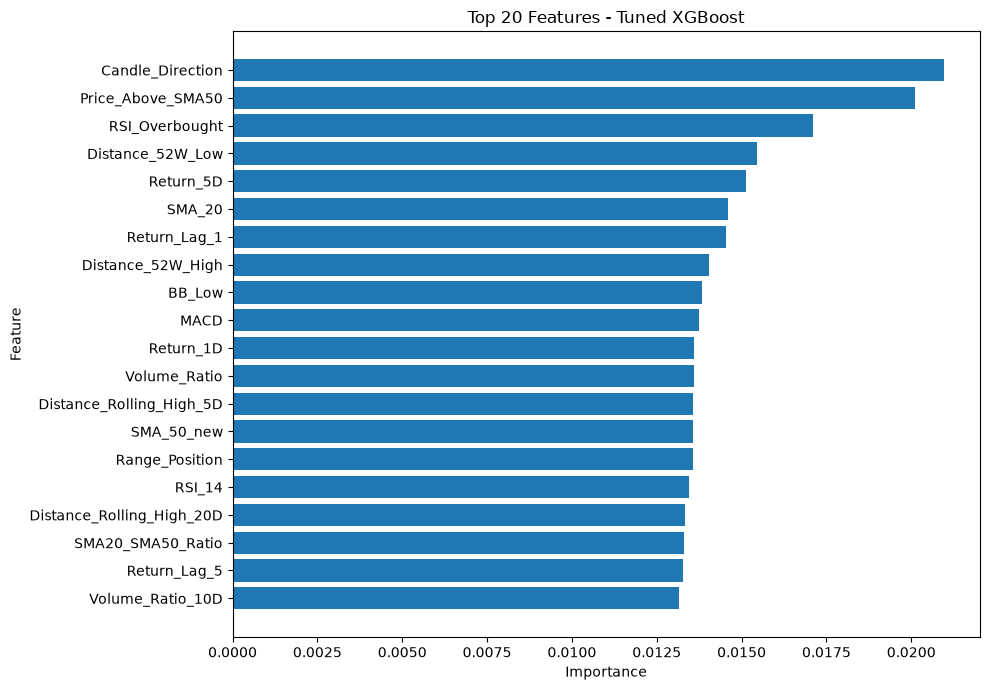

In [57]:
top_features = tuned_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Tuned XGBoost")

plt.tight_layout()
plt.show()

In [58]:
importance_sorted = (
    tuned_importance["Importance"]
)

print(
    "Top 10 importance:",
    importance_sorted.head(10).sum()
)

print(
    "Top 20 importance:",
    importance_sorted.head(20).sum()
)

print(
    "Top 40 importance:",
    importance_sorted.head(40).sum()
)

Top 10 importance: 0.15953168
Top 20 importance: 0.29393977
Top 40 importance: 0.5498009


In [59]:
top_20_features = (
    tuned_importance
    .head(20)["Feature"]
    .tolist()
)

top_40_features = (
    tuned_importance
    .head(40)["Feature"]
    .tolist()
)

print("Top 20:", top_20_features)
print()
print("Top 40:", top_40_features)

Top 20: ['Candle_Direction', 'Price_Above_SMA50', 'RSI_Overbought', 'Distance_52W_Low', 'Return_5D', 'SMA_20', 'Return_Lag_1', 'Distance_52W_High', 'BB_Low', 'MACD', 'Return_1D', 'Volume_Ratio', 'Distance_Rolling_High_5D', 'SMA_50_new', 'Range_Position', 'RSI_14', 'Distance_Rolling_High_20D', 'SMA20_SMA50_Ratio', 'Return_Lag_5', 'Volume_Ratio_10D']

Top 40: ['Candle_Direction', 'Price_Above_SMA50', 'RSI_Overbought', 'Distance_52W_Low', 'Return_5D', 'SMA_20', 'Return_Lag_1', 'Distance_52W_High', 'BB_Low', 'MACD', 'Return_1D', 'Volume_Ratio', 'Distance_Rolling_High_5D', 'SMA_50_new', 'Range_Position', 'RSI_14', 'Distance_Rolling_High_20D', 'SMA20_SMA50_Ratio', 'Return_Lag_5', 'Volume_Ratio_10D', 'Momentum_5D_pct', 'Close_Lag_3', 'Trend_Strength_20D', 'EMA12_vs_EMA26', 'Price_vs_SMA50', 'Price_vs_SMA20', 'ATR_14', 'ROC_20', 'High_Low_Range', 'MACD_Diff', 'Rolling_Low_20D', 'Volume_SMA_10', 'Rolling_High_20D', 'EMA_26', 'MACD_Signal', 'BB_High', 'Momentum_5D', 'Upper_Shadow', 'Lower_Shadow

In [60]:
xgb_top20 = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_top20.fit(
    X_train[top_20_features],
    y_train
)

top20_predictions = xgb_top20.predict(
    X_validation[top_20_features]
)

top20_results = {
    "Accuracy": accuracy_score(
        y_validation,
        top20_predictions
    ),
    "Precision": precision_score(
        y_validation,
        top20_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        top20_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        top20_predictions,
        zero_division=0
    )
}

print(top20_results)

{'Accuracy': 0.5096119726982404, 'Precision': 0.5187351347136118, 'Recall': 0.5440196278879574, 'F1': 0.531076603728394}


In [61]:
xgb_top40 = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_top40.fit(
    X_train[top_40_features],
    y_train
)

top40_predictions = xgb_top40.predict(
    X_validation[top_40_features]
)

top40_results = {
    "Accuracy": accuracy_score(
        y_validation,
        top40_predictions
    ),
    "Precision": precision_score(
        y_validation,
        top40_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        top40_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        top40_predictions,
        zero_division=0
    )
}

print(top40_results)

{'Accuracy': 0.5092571333152435, 'Precision': 0.521240212402124, 'Recall': 0.47364547127376816, 'F1': 0.49630438974227137}


In [62]:
feature_comparison = pd.DataFrame([
    {
        "Feature_Set": "All 82",
        **tuning_results_df.iloc[0][
            ["Accuracy", "Precision", "Recall", "F1"]
        ].to_dict()
    },
    {
        "Feature_Set": "Top 40",
        **top40_results
    },
    {
        "Feature_Set": "Top 20",
        **top20_results
    }
])

feature_comparison

,Feature_Set,Accuracy,Precision,Recall,F1
0,All 82,0.512931,0.523681,0.506400,0.514895
1,Top 40,0.509257,0.521240,0.473645,0.496304
2,Top 20,0.509612,0.518735,0.544020,0.531077


In [63]:
market_daily = (
    df.groupby("Date")
    .agg(
        Market_Return=("Return_1D", "mean"),
        Market_Volatility=("Return_1D", "std"),
        Market_Momentum_5D=("Return_5D", "mean"),
        Market_Momentum_20D=("Return_20D", "mean")
    )
    .reset_index()
)

print(market_daily.head())
print(market_daily.shape)

                       Date  Market_Return  Market_Volatility  \
0 1999-04-08 00:00:00+05:30      -0.008994           0.024443   
1 1999-04-12 00:00:00+05:30       0.002947           0.026027   
2 1999-04-13 00:00:00+05:30      -0.013707           0.019553   
3 1999-04-16 00:00:00+05:30       0.075807           0.025262   
4 1999-04-19 00:00:00+05:30      -0.023051           0.030107   

   Market_Momentum_5D  Market_Momentum_20D  
0           -0.054279            -0.014992  
1           -0.017777            -0.036178  
2           -0.040283            -0.033524  
3            0.035407             0.002471  
4            0.007483            -0.029290  
(6519, 5)


In [64]:
market_breadth = (
    df.groupby("Date")["Return_1D"]
    .apply(lambda x: (x > 0).mean())
    .reset_index(name="Market_Breadth")
)

market_daily = market_daily.merge(
    market_breadth,
    on="Date",
    how="left"
)

print(market_daily.head())

                       Date  Market_Return  Market_Volatility  \
0 1999-04-08 00:00:00+05:30      -0.008994           0.024443   
1 1999-04-12 00:00:00+05:30       0.002947           0.026027   
2 1999-04-13 00:00:00+05:30      -0.013707           0.019553   
3 1999-04-16 00:00:00+05:30       0.075807           0.025262   
4 1999-04-19 00:00:00+05:30      -0.023051           0.030107   

   Market_Momentum_5D  Market_Momentum_20D  Market_Breadth  
0           -0.054279            -0.014992            0.25  
1           -0.017777            -0.036178            0.40  
2           -0.040283            -0.033524            0.15  
3            0.035407             0.002471            0.95  
4            0.007483            -0.029290            0.20  


In [65]:
market_daily["Market_SMA_5"] = (
    market_daily["Market_Return"]
    .rolling(5)
    .mean()
)

market_daily["Market_SMA_20"] = (
    market_daily["Market_Return"]
    .rolling(20)
    .mean()
)

market_daily["Market_Return_Lag_1"] = (
    market_daily["Market_Return"].shift(1)
)

market_daily["Market_Return_Lag_5"] = (
    market_daily["Market_Return"].shift(5)
)

In [66]:
market_features = [
    "Market_Return",
    "Market_Volatility",
    "Market_Momentum_5D",
    "Market_Momentum_20D",
    "Market_Breadth",
    "Market_SMA_5",
    "Market_SMA_20",
    "Market_Return_Lag_1",
    "Market_Return_Lag_5"
]

df = df.merge(
    market_daily[
        ["Date"] + market_features
    ],
    on="Date",
    how="left"
)

print(df.shape)
print(df[market_features].isnull().sum())

(275531, 94)
Market_Return            0
Market_Volatility       15
Market_Momentum_5D       0
Market_Momentum_20D      0
Market_Breadth           0
Market_SMA_5            80
Market_SMA_20          377
Market_Return_Lag_1     20
Market_Return_Lag_5    100
dtype: int64


In [67]:
feature_columns_market = (
    feature_columns +
    market_features
)

print(
    "Original features:",
    len(feature_columns)
)

print(
    "New features:",
    len(feature_columns_market)
)

Original features: 82
New features: 91


In [68]:
df = df.dropna(
    subset=feature_columns_market + ["Target"]
).reset_index(drop=True)

print(df.shape)

(275139, 94)


In [69]:
X_market = df[
    feature_columns_market
].copy()

y_market = df[
    "Target"
].copy()

print(X_market.shape)
print(y_market.shape)

(275139, 91)
(275139,)


In [70]:
unique_dates = np.sort(
    df["Date"].unique()
)

n_dates = len(unique_dates)

train_end_index = int(
    n_dates * 0.70
)

validation_end_index = int(
    n_dates * 0.85
)

train_end_date = unique_dates[
    train_end_index - 1
]

validation_end_date = unique_dates[
    validation_end_index - 1
]

train_mask_market = (
    df["Date"] <= train_end_date
)

validation_mask_market = (
    (df["Date"] > train_end_date) &
    (df["Date"] <= validation_end_date)
)

test_mask_market = (
    df["Date"] > validation_end_date
)

In [71]:
X_train_market = X_market.loc[
    train_mask_market
]

y_train_market = y_market.loc[
    train_mask_market
]

X_validation_market = X_market.loc[
    validation_mask_market
]

y_validation_market = y_market.loc[
    validation_mask_market
]

X_test_market = X_market.loc[
    test_mask_market
]

y_test_market = y_market.loc[
    test_mask_market
]

print("Train:", X_train_market.shape)
print("Validation:", X_validation_market.shape)
print("Test:", X_test_market.shape)

Train: (179823, 91)
Validation: (47665, 91)
Test: (47651, 91)


In [72]:
xgb_market = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_market.fit(
    X_train_market,
    y_train_market
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [73]:
market_validation_predictions = (
    xgb_market.predict(
        X_validation_market
    )
)

market_validation_results = {
    "Accuracy": accuracy_score(
        y_validation_market,
        market_validation_predictions
    ),
    "Precision": precision_score(
        y_validation_market,
        market_validation_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation_market,
        market_validation_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation_market,
        market_validation_predictions,
        zero_division=0
    )
}

print(market_validation_results)

{'Accuracy': 0.5175705444246302, 'Precision': 0.530863646507476, 'Recall': 0.4878989252604808, 'F1': 0.508475300857149}


In [74]:
market_importance = pd.DataFrame({
    "Feature": feature_columns_market,
    "Importance": xgb_market.feature_importances_
})

market_importance = (
    market_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

market_importance.head(25)

,Feature,Importance
0,Market_Return,0.023574
1,Market_Momentum_5D,0.023206
2,Market_Momentum_20D,0.022539
3,Market_SMA_20,0.022418
4,Market_SMA_5,0.022190
5,Market_Return_Lag_1,0.022087
6,Market_Return_Lag_5,0.021765
7,Market_Volatility,0.021319
8,Market_Breadth,0.021288
9,MACD_Bullish,0.016603


In [75]:
df["Relative_Market_Return"] = (
    df["Return_1D"] - df["Market_Return"]
)

df["Relative_Momentum_5D"] = (
    df["Return_5D"] - df["Market_Momentum_5D"]
)

df["Relative_Momentum_20D"] = (
    df["Return_20D"] - df["Market_Momentum_20D"]
)

df["Relative_Volatility"] = (
    df["Volatility_20D_new"] -
    df["Market_Volatility"]
)

print(
    df[
        [
            "Relative_Market_Return",
            "Relative_Momentum_5D",
            "Relative_Momentum_20D",
            "Relative_Volatility"
        ]
    ].head()
)

   Relative_Market_Return  Relative_Momentum_5D  Relative_Momentum_20D  \
0               -0.012375             -0.094190              -0.142047   
1                0.060153              0.270169               0.110982   
2               -0.034022             -0.103980              -0.279865   
3                0.005342             -0.018887              -0.268884   
4               -0.065756             -0.001296               0.076524   

   Relative_Volatility  
0            -0.015343  
1             0.021058  
2            -0.005410  
3            -0.009575  
4            -0.001955  


In [76]:
df["Relative_Market_Return"] = (
    df["Return_1D"] - df["Market_Return"]
)

df["Relative_Momentum_5D"] = (
    df["Return_5D"] - df["Market_Momentum_5D"]
)

df["Relative_Momentum_20D"] = (
    df["Return_20D"] - df["Market_Momentum_20D"]
)

df["Relative_Volatility"] = (
    df["Volatility_20D_new"] -
    df["Market_Volatility"]
)

print(
    df[
        [
            "Relative_Market_Return",
            "Relative_Momentum_5D",
            "Relative_Momentum_20D",
            "Relative_Volatility"
        ]
    ].head()
)

   Relative_Market_Return  Relative_Momentum_5D  Relative_Momentum_20D  \
0               -0.012375             -0.094190              -0.142047   
1                0.060153              0.270169               0.110982   
2               -0.034022             -0.103980              -0.279865   
3                0.005342             -0.018887              -0.268884   
4               -0.065756             -0.001296               0.076524   

   Relative_Volatility  
0            -0.015343  
1             0.021058  
2            -0.005410  
3            -0.009575  
4            -0.001955  


In [77]:
relative_features = [
    "Relative_Market_Return",
    "Relative_Momentum_5D",
    "Relative_Momentum_20D",
    "Relative_Volatility"
]

feature_columns_market_relative = (
    feature_columns_market +
    relative_features
)

print(
    "Total features:",
    len(feature_columns_market_relative)
)

Total features: 95


In [78]:
print(
    df[
        feature_columns_market_relative
    ].isnull().sum().sum()
)

0


In [79]:
X_relative = df[
    feature_columns_market_relative
].copy()

y_relative = df[
    "Target"
].copy()

print("X:", X_relative.shape)
print("y:", y_relative.shape)

X: (275139, 95)
y: (275139,)


In [80]:
unique_dates = np.sort(
    df["Date"].unique()
)

n_dates = len(unique_dates)

train_end_index = int(
    n_dates * 0.70
)

validation_end_index = int(
    n_dates * 0.85
)

train_end_date = unique_dates[
    train_end_index - 1
]

validation_end_date = unique_dates[
    validation_end_index - 1
]

train_mask_relative = (
    df["Date"] <= train_end_date
)

validation_mask_relative = (
    (df["Date"] > train_end_date) &
    (df["Date"] <= validation_end_date)
)

test_mask_relative = (
    df["Date"] > validation_end_date
)

In [81]:
X_train_relative = X_relative.loc[
    train_mask_relative
]

y_train_relative = y_relative.loc[
    train_mask_relative
]

X_validation_relative = X_relative.loc[
    validation_mask_relative
]

y_validation_relative = y_relative.loc[
    validation_mask_relative
]

X_test_relative = X_relative.loc[
    test_mask_relative
]

y_test_relative = y_relative.loc[
    test_mask_relative
]

print("Train:", X_train_relative.shape)
print("Validation:", X_validation_relative.shape)
print("Test:", X_test_relative.shape)

Train: (179823, 95)
Validation: (47665, 95)
Test: (47651, 95)


In [82]:
xgb_relative = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_relative.fit(
    X_train_relative,
    y_train_relative
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [83]:
relative_predictions = (
    xgb_relative.predict(
        X_validation_relative
    )
)

relative_results = {
    "Accuracy": accuracy_score(
        y_validation_relative,
        relative_predictions
    ),
    "Precision": precision_score(
        y_validation_relative,
        relative_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation_relative,
        relative_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation_relative,
        relative_predictions,
        zero_division=0
    )
}

print(relative_results)

{'Accuracy': 0.5161019616070492, 'Precision': 0.5287421741605008, 'Recall': 0.4954056936582164, 'F1': 0.5115313750820645}


In [84]:
relative_importance = pd.DataFrame({
    "Feature": feature_columns_market_relative,
    "Importance": xgb_relative.feature_importances_
})

relative_importance = (
    relative_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

relative_importance.head(25)

,Feature,Importance
0,Market_Return,0.022820
1,Market_Momentum_5D,0.022475
2,Market_Momentum_20D,0.022170
3,Market_Return_Lag_1,0.021999
4,Market_SMA_20,0.021981
5,Market_Return_Lag_5,0.020871
6,Market_Breadth,0.020811
7,Market_SMA_5,0.020622
8,Market_Volatility,0.019741
9,MACD_Bullish,0.016414


In [85]:
comparison_day3 = pd.DataFrame([
    {
        "Experiment": "Technical Only",
        "Accuracy": 0.512931
    },
    {
        "Experiment": "Technical + Market",
        "Accuracy": market_validation_results["Accuracy"]
    },
    {
        "Experiment": "Technical + Market + Relative",
        "Accuracy": relative_results["Accuracy"]
    }
])

comparison_day3

,Experiment,Accuracy
0,Technical Only,0.512931
1,Technical + Market,0.517571
2,Technical + Market + Relative,0.516102


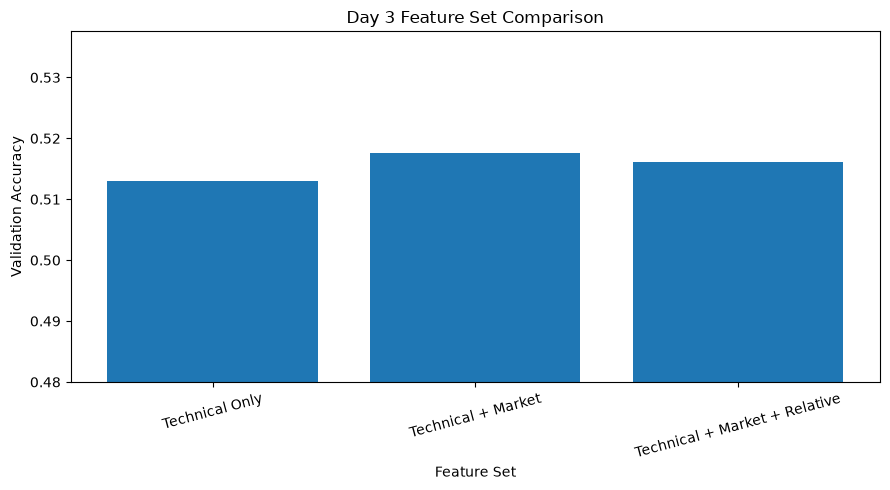

In [86]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_day3["Experiment"],
    comparison_day3["Accuracy"]
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Feature Set")
plt.title("Day 3 Feature Set Comparison")

plt.ylim(
    0.48,
    max(comparison_day3["Accuracy"]) + 0.02
)

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()

In [87]:
comparison_day3.to_csv(
    "../data/processed/day3_feature_comparison.csv",
    index=False
)

print("Comparison saved.")

Comparison saved.


In [88]:
data_path = "../data/processed/stock_model_dataset.csv"

df = pd.read_csv(data_path)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

print("Shape:", df.shape)
print("Stocks:", df["Ticker"].nunique())
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

Shape: (275531, 85)
Stocks: 49
Start: 1999-04-08 00:00:00+05:30
End: 2026-01-30 00:00:00+05:30


In [89]:
feature_list_path = "../data/processed/feature_list.csv"

feature_columns = pd.read_csv(
    feature_list_path
)["Feature"].tolist()

print("Technical features:", len(feature_columns))

Technical features: 82


In [90]:
market_daily = (
    df.groupby("Date")
    .agg(
        Market_Return=("Return_1D", "mean"),
        Market_Volatility=("Return_1D", "std"),
        Market_Momentum_5D=("Return_5D", "mean"),
        Market_Momentum_20D=("Return_20D", "mean")
    )
    .reset_index()
)

market_breadth = (
    df.groupby("Date")["Return_1D"]
    .apply(lambda x: (x > 0).mean())
    .reset_index(name="Market_Breadth")
)

market_daily = market_daily.merge(
    market_breadth,
    on="Date",
    how="left"
)

market_daily = market_daily.sort_values(
    "Date"
).reset_index(drop=True)

market_daily["Market_SMA_5"] = (
    market_daily["Market_Return"]
    .rolling(5)
    .mean()
)

market_daily["Market_SMA_20"] = (
    market_daily["Market_Return"]
    .rolling(20)
    .mean()
)

market_daily["Market_Return_Lag_1"] = (
    market_daily["Market_Return"].shift(1)
)

market_daily["Market_Return_Lag_5"] = (
    market_daily["Market_Return"].shift(5)
)

In [91]:
market_features = [
    "Market_Return",
    "Market_Volatility",
    "Market_Momentum_5D",
    "Market_Momentum_20D",
    "Market_Breadth",
    "Market_SMA_5",
    "Market_SMA_20",
    "Market_Return_Lag_1",
    "Market_Return_Lag_5"
]

print("Market features:", len(market_features))

Market features: 9


In [92]:
df = df.merge(
    market_daily[
        ["Date"] + market_features
    ],
    on="Date",
    how="left"
)

print(df.shape)

(275531, 94)


In [93]:
raw_path = "../data/raw/nifty50_historical_data.csv"

sector_data = pd.read_csv(
    raw_path,
    usecols=["Ticker", "Sector"]
)

sector_data = sector_data.drop_duplicates()

print(sector_data.head())
print("Rows:", len(sector_data))
print("Unique stocks:", sector_data["Ticker"].nunique())

         Ticker      Sector
0   AXISBANK.NS  Financials
1       BPCL.NS      Energy
2  BRITANNIA.NS        FMCG
3      CIPLA.NS      Pharma
4    DRREDDY.NS      Pharma
Rows: 49
Unique stocks: 49


In [94]:
sector_check = (
    sector_data
    .groupby("Ticker")["Sector"]
    .nunique()
)

print(sector_check.value_counts())

Sector
1    49
Name: count, dtype: int64


In [95]:
sector_map = (
    sector_data
    .drop_duplicates("Ticker")
)

print(
    sector_map.head(20)
)

           Ticker             Sector
0     AXISBANK.NS         Financials
1         BPCL.NS             Energy
2    BRITANNIA.NS               FMCG
3        CIPLA.NS             Pharma
4      DRREDDY.NS             Pharma
5    EICHERMOT.NS         Automobile
6     HDFCBANK.NS         Financials
7     HINDALCO.NS             Metals
8   HINDUNILVR.NS               FMCG
9         INFY.NS                 IT
10         ITC.NS               FMCG
11         M&M.NS         Automobile
12        ONGC.NS             Energy
13    RELIANCE.NS             Energy
14        SBIN.NS         Financials
15   SUNPHARMA.NS             Pharma
16  TATACONSUM.NS               FMCG
17   TATASTEEL.NS             Metals
18       TITAN.NS  Consumer Durables
19       WIPRO.NS                 IT


In [96]:
df = df.drop(
    columns=["Sector"],
    errors="ignore"
)

df = df.merge(
    sector_map,
    on="Ticker",
    how="left"
)

print("Shape:", df.shape)

print(
    "Missing Sector:",
    df["Sector"].isnull().sum()
)

Shape: (275531, 95)
Missing Sector: 0


In [97]:
print(
    df[["Ticker", "Sector"]].head(20)
)

           Ticker             Sector
0     AXISBANK.NS         Financials
1         BPCL.NS             Energy
2    BRITANNIA.NS               FMCG
3        CIPLA.NS             Pharma
4      DRREDDY.NS             Pharma
5    EICHERMOT.NS         Automobile
6     HDFCBANK.NS         Financials
7     HINDALCO.NS             Metals
8   HINDUNILVR.NS               FMCG
9         INFY.NS                 IT
10         ITC.NS               FMCG
11         M&M.NS         Automobile
12        ONGC.NS             Energy
13    RELIANCE.NS             Energy
14        SBIN.NS         Financials
15   SUNPHARMA.NS             Pharma
16  TATACONSUM.NS               FMCG
17   TATASTEEL.NS             Metals
18       TITAN.NS  Consumer Durables
19       WIPRO.NS                 IT


In [98]:
print(
    df["Sector"].value_counts()
)

Sector
Financials           51996
IT                   30951
FMCG                 29997
Automobile           29749
Pharma               25041
Metals               22118
Energy               19506
Cement               17276
Infrastructure       15730
Consumer Durables    12196
Power                 9577
Healthcare            5697
Telecom               5697
Name: count, dtype: int64


In [99]:
market_daily = (
    df.groupby("Date")
    .agg(
        Market_Return=("Return_1D", "mean"),
        Market_Volatility=("Return_1D", "std"),
        Market_Momentum_5D=("Return_5D", "mean"),
        Market_Momentum_20D=("Return_20D", "mean")
    )
    .reset_index()
)

In [100]:
market_breadth = (
    df.groupby("Date")["Return_1D"]
    .apply(
        lambda x: (x > 0).mean()
    )
    .reset_index(
        name="Market_Breadth"
    )
)

market_daily = market_daily.merge(
    market_breadth,
    on="Date",
    how="left"
)

In [101]:
market_daily = market_daily.sort_values(
    "Date"
).reset_index(drop=True)

market_daily["Market_SMA_5"] = (
    market_daily["Market_Return"]
    .rolling(5)
    .mean()
)

market_daily["Market_SMA_20"] = (
    market_daily["Market_Return"]
    .rolling(20)
    .mean()
)

market_daily["Market_Return_Lag_1"] = (
    market_daily["Market_Return"].shift(1)
)

market_daily["Market_Return_Lag_5"] = (
    market_daily["Market_Return"].shift(5)
)

In [102]:
market_features = [
    "Market_Return",
    "Market_Volatility",
    "Market_Momentum_5D",
    "Market_Momentum_20D",
    "Market_Breadth",
    "Market_SMA_5",
    "Market_SMA_20",
    "Market_Return_Lag_1",
    "Market_Return_Lag_5"
]

print(
    "Market features:",
    len(market_features)
)

Market features: 9


In [103]:
df = df.merge(
    market_daily[
        ["Date"] + market_features
    ],
    on="Date",
    how="left"
)

print(df.shape)

(275531, 104)


In [104]:
sector_daily = (
    df.groupby(
        ["Date", "Sector"]
    )
    .agg(
        Sector_Return=("Return_1D", "mean"),
        Sector_Volatility=("Return_1D", "std"),
        Sector_Momentum_5D=("Return_5D", "mean"),
        Sector_Momentum_20D=("Return_20D", "mean")
    )
    .reset_index()
)

print(
    sector_daily.head(20)
)

                        Date             Sector  Sector_Return  \
0  1999-04-08 00:00:00+05:30         Automobile       0.015944   
1  1999-04-08 00:00:00+05:30  Consumer Durables      -0.017615   
2  1999-04-08 00:00:00+05:30             Energy      -0.000538   
3  1999-04-08 00:00:00+05:30               FMCG      -0.025943   
4  1999-04-08 00:00:00+05:30         Financials      -0.015403   
5  1999-04-08 00:00:00+05:30                 IT      -0.004253   
6  1999-04-08 00:00:00+05:30             Metals      -0.007138   
7  1999-04-08 00:00:00+05:30             Pharma      -0.006596   
8  1999-04-12 00:00:00+05:30         Automobile       0.039199   
9  1999-04-12 00:00:00+05:30  Consumer Durables      -0.003718   
10 1999-04-12 00:00:00+05:30             Energy      -0.007722   
11 1999-04-12 00:00:00+05:30               FMCG       0.015087   
12 1999-04-12 00:00:00+05:30         Financials      -0.006037   
13 1999-04-12 00:00:00+05:30                 IT       0.000499   
14 1999-04

In [105]:
sector_breadth = (
    df.groupby(
        ["Date", "Sector"]
    )["Return_1D"]
    .apply(
        lambda x: (x > 0).mean()
    )
    .reset_index(
        name="Sector_Breadth"
    )
)

sector_daily = sector_daily.merge(
    sector_breadth,
    on=["Date", "Sector"],
    how="left"
)

In [106]:
sector_daily = sector_daily.sort_values(
    ["Sector", "Date"]
).reset_index(drop=True)

sector_daily["Sector_Return_Lag_1"] = (
    sector_daily
    .groupby("Sector")["Sector_Return"]
    .shift(1)
)

sector_daily["Sector_Return_Lag_5"] = (
    sector_daily
    .groupby("Sector")["Sector_Return"]
    .shift(5)
)

sector_daily["Sector_SMA_5"] = (
    sector_daily
    .groupby("Sector")["Sector_Return"]
    .transform(
        lambda x: x.rolling(5).mean()
    )
)

sector_daily["Sector_SMA_20"] = (
    sector_daily
    .groupby("Sector")["Sector_Return"]
    .transform(
        lambda x: x.rolling(20).mean()
    )
)

In [107]:
sector_features = [
    "Sector_Return",
    "Sector_Volatility",
    "Sector_Momentum_5D",
    "Sector_Momentum_20D",
    "Sector_Breadth",
    "Sector_Return_Lag_1",
    "Sector_Return_Lag_5",
    "Sector_SMA_5",
    "Sector_SMA_20"
]

print(
    "Sector features:",
    len(sector_features)
)

Sector features: 9


In [108]:
df = df.merge(
    sector_daily[
        ["Date", "Sector"] + sector_features
    ],
    on=["Date", "Sector"],
    how="left"
)

print(
    "Shape:",
    df.shape
)

Shape: (275531, 113)


In [109]:
feature_list_path = (
    "../data/processed/feature_list.csv"
)

feature_columns = pd.read_csv(
    feature_list_path
)["Feature"].tolist()

print(
    "Technical features:",
    len(feature_columns)
)

Technical features: 82


In [110]:
feature_columns_sector = (
    feature_columns
    + market_features
    + sector_features
)

print(
    "Technical:",
    len(feature_columns)
)

print(
    "Market:",
    len(market_features)
)

print(
    "Sector:",
    len(sector_features)
)

print(
    "TOTAL:",
    len(feature_columns_sector)
)

Technical: 82
Market: 9
Sector: 9
TOTAL: 100


In [115]:
market_cols_to_remove = [
    col for col in df.columns
    if col in market_features
    or col.endswith("_x")
    or col.endswith("_y")
]

df = df.drop(
    columns=market_cols_to_remove,
    errors="ignore"
)

df = df.merge(
    market_daily[
        ["Date"] + market_features
    ],
    on="Date",
    how="left"
)

print(
    [col for col in market_features if col in df.columns]
)

['Market_Return', 'Market_Volatility', 'Market_Momentum_5D', 'Market_Momentum_20D', 'Market_Breadth', 'Market_SMA_5', 'Market_SMA_20', 'Market_Return_Lag_1', 'Market_Return_Lag_5']


In [116]:
print(
    "Missing market columns:",
    [
        col for col in market_features
        if col not in df.columns
    ]
)

Missing market columns: []


In [117]:
missing = (
    df[
        feature_columns_sector + ["Target"]
    ]
    .isnull()
    .sum()
)

print(
    missing[missing > 0]
)

Market_Volatility         15
Market_SMA_5              80
Market_SMA_20            377
Market_Return_Lag_1       20
Market_Return_Lag_5      100
Sector_Volatility      13251
Sector_Return_Lag_1       26
Sector_Return_Lag_5      130
Sector_SMA_5             104
Sector_SMA_20            491
dtype: int64


In [118]:
df = df.dropna(
    subset=feature_columns_sector + ["Target"]
).reset_index(drop=True)

print(
    "Final shape:",
    df.shape
)

Final shape: (261884, 104)


In [119]:
X = df[
    feature_columns_sector
].copy()

y = df[
    "Target"
].copy()

print(
    "X:",
    X.shape
)

print(
    "y:",
    y.shape
)

X: (261884, 100)
y: (261884,)


In [120]:
unique_dates = np.sort(
    df["Date"].unique()
)

n_dates = len(unique_dates)

train_end_index = int(
    n_dates * 0.70
)

validation_end_index = int(
    n_dates * 0.85
)

train_end_date = unique_dates[
    train_end_index - 1
]

validation_end_date = unique_dates[
    validation_end_index - 1
]

train_mask = (
    df["Date"] <= train_end_date
)

validation_mask = (
    (df["Date"] > train_end_date) &
    (df["Date"] <= validation_end_date)
)

test_mask = (
    df["Date"] > validation_end_date
)

In [121]:
X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_validation = X.loc[validation_mask]
y_validation = y.loc[validation_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print(
    "Train:",
    X_train.shape
)

print(
    "Validation:",
    X_validation.shape
)

print(
    "Test:",
    X_test.shape
)

Train: (170460, 100)
Validation: (45719, 100)
Test: (45705, 100)


In [122]:
xgb_sector = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_sector.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [123]:
sector_predictions = (
    xgb_sector.predict(
        X_validation
    )
)

sector_results = {
    "Accuracy": accuracy_score(
        y_validation,
        sector_predictions
    ),
    "Precision": precision_score(
        y_validation,
        sector_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        sector_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        sector_predictions,
        zero_division=0
    )
}

print(sector_results)

{'Accuracy': 0.5156936940877972, 'Precision': 0.5288308378464479, 'Recall': 0.49639027724379514, 'F1': 0.5120973073024547}


In [124]:
sector_importance = pd.DataFrame({
    "Feature": feature_columns_sector,
    "Importance": xgb_sector.feature_importances_
})

sector_importance = (
    sector_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

sector_importance.head(25)

,Feature,Importance
0,Market_Return,0.020770
1,Market_Momentum_20D,0.020031
2,Market_Momentum_5D,0.019647
3,Market_Return_Lag_1,0.019424
4,Market_SMA_20,0.019321
5,Market_Return_Lag_5,0.019264
6,Market_SMA_5,0.019245
7,High_Volatility,0.018881
8,Market_Volatility,0.018401
9,Market_Breadth,0.017934


In [125]:
print("Shape:", df.shape)
print("Sector exists:", "Sector" in df.columns)
print("Market columns:")
print([c for c in market_features if c in df.columns])

Shape: (261884, 104)
Sector exists: True
Market columns:
['Market_Return', 'Market_Volatility', 'Market_Momentum_5D', 'Market_Momentum_20D', 'Market_Breadth', 'Market_SMA_5', 'Market_SMA_20', 'Market_Return_Lag_1', 'Market_Return_Lag_5']


In [126]:
sector_daily = (
    df.groupby(["Date", "Sector"])
    .agg(
        Sector_Return=("Return_1D", "mean"),
        Sector_Volatility=("Return_1D", "std"),
        Sector_Momentum_5D=("Return_5D", "mean"),
        Sector_Momentum_20D=("Return_20D", "mean")
    )
    .reset_index()
)

sector_breadth = (
    df.groupby(["Date", "Sector"])["Return_1D"]
    .apply(lambda x: (x > 0).mean())
    .reset_index(name="Sector_Breadth")
)

sector_daily = sector_daily.merge(
    sector_breadth,
    on=["Date", "Sector"],
    how="left"
)

sector_daily = sector_daily.sort_values(
    ["Sector", "Date"]
).reset_index(drop=True)

In [127]:
sector_daily["Sector_Return_Lag_1"] = (
    sector_daily.groupby("Sector")["Sector_Return"].shift(1)
)

sector_daily["Sector_Return_Lag_5"] = (
    sector_daily.groupby("Sector")["Sector_Return"].shift(5)
)

sector_daily["Sector_SMA_5"] = (
    sector_daily.groupby("Sector")["Sector_Return"]
    .transform(lambda x: x.rolling(5).mean())
)

sector_daily["Sector_SMA_20"] = (
    sector_daily.groupby("Sector")["Sector_Return"]
    .transform(lambda x: x.rolling(20).mean())
)

In [128]:
sector_features = [
    "Sector_Return",
    "Sector_Volatility",
    "Sector_Momentum_5D",
    "Sector_Momentum_20D",
    "Sector_Breadth",
    "Sector_Return_Lag_1",
    "Sector_Return_Lag_5",
    "Sector_SMA_5",
    "Sector_SMA_20"
]

df = df.drop(
    columns=sector_features,
    errors="ignore"
)

df = df.merge(
    sector_daily[
        ["Date", "Sector"] + sector_features
    ],
    on=["Date", "Sector"],
    how="left"
)

print("Shape:", df.shape)

Shape: (261884, 104)


In [129]:
feature_columns_sector = (
    feature_columns
    + market_features
    + sector_features
)

print("Technical:", len(feature_columns))
print("Market:", len(market_features))
print("Sector:", len(sector_features))
print("Total:", len(feature_columns_sector))

Technical: 82
Market: 9
Sector: 9
Total: 100


In [130]:
missing_features = [
    col for col in feature_columns_sector
    if col not in df.columns
]

print("Missing features:", missing_features)

Missing features: []


In [131]:
df_model = df.dropna(
    subset=feature_columns_sector + ["Target"]
).copy()

print("Original:", df.shape)
print("Model data:", df_model.shape)

Original: (261884, 104)
Model data: (261371, 104)


In [132]:
X = df_model[
    feature_columns_sector
].copy()

y = df_model[
    "Target"
].copy()

print("X:", X.shape)
print("y:", y.shape)

X: (261371, 100)
y: (261371,)


In [133]:
unique_dates = np.sort(
    df_model["Date"].unique()
)

n_dates = len(unique_dates)

train_end_index = int(n_dates * 0.70)
validation_end_index = int(n_dates * 0.85)

train_end_date = unique_dates[
    train_end_index - 1
]

validation_end_date = unique_dates[
    validation_end_index - 1
]

print("Train end:", train_end_date)
print("Validation end:", validation_end_date)

Train end: 2018-03-15 00:00:00+05:30
Validation end: 2022-02-17 00:00:00+05:30


In [134]:
train_mask = (
    df_model["Date"] <= train_end_date
)

validation_mask = (
    (df_model["Date"] > train_end_date) &
    (df_model["Date"] <= validation_end_date)
)

test_mask = (
    df_model["Date"] > validation_end_date
)

In [135]:
X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_validation = X.loc[validation_mask]
y_validation = y.loc[validation_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

Train: (170229, 100)
Validation: (45578, 100)
Test: (45564, 100)


In [136]:
xgb_sector = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_sector.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [137]:
sector_predictions = xgb_sector.predict(
    X_validation
)

sector_results = {
    "Accuracy": accuracy_score(
        y_validation,
        sector_predictions
    ),
    "Precision": precision_score(
        y_validation,
        sector_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        sector_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        sector_predictions,
        zero_division=0
    )
}

print(sector_results)

{'Accuracy': 0.5138443986133661, 'Precision': 0.5272058138451504, 'Recall': 0.4851667666981051, 'F1': 0.5053134488301483}


In [138]:
sector_importance = pd.DataFrame({
    "Feature": feature_columns_sector,
    "Importance": xgb_sector.feature_importances_
})

sector_importance = (
    sector_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

sector_importance.head(25)

,Feature,Importance
0,Market_Return,0.021408
1,Market_SMA_20,0.020169
2,Market_SMA_5,0.019916
3,Market_Return_Lag_1,0.019898
4,Market_Momentum_20D,0.019714
5,Market_Volatility,0.019624
6,Market_Momentum_5D,0.019560
7,Market_Return_Lag_5,0.019545
8,SMA_10,0.018580
9,Market_Breadth,0.018439


In [139]:
technical_importance = (
    sector_importance[
        sector_importance["Feature"].isin(
            feature_columns
        )
    ]["Importance"].sum()
)

market_importance_total = (
    sector_importance[
        sector_importance["Feature"].isin(
            market_features
        )
    ]["Importance"].sum()
)

sector_importance_total = (
    sector_importance[
        sector_importance["Feature"].isin(
            sector_features
        )
    ]["Importance"].sum()
)

print("Technical importance:", technical_importance)
print("Market importance:", market_importance_total)
print("Sector importance:", sector_importance_total)

Technical importance: 0.72577786
Market importance: 0.17827393
Sector importance: 0.095948115


In [140]:
market_accuracy = 0.517571
sector_accuracy = sector_results["Accuracy"]

if sector_accuracy > market_accuracy:
    final_features = feature_columns_sector
    final_feature_name = "Technical + Market + Sector"
else:
    final_features = feature_columns_market
    final_feature_name = "Technical + Market"

print(
    "Selected feature set:",
    final_feature_name
)

print(
    "Number of features:",
    len(final_features)
)

Selected feature set: Technical + Market
Number of features: 91


In [141]:
feature_columns_market = (
    feature_columns + market_features
)

In [142]:
X_final = df_model[
    final_features
].copy()

y_final = df_model[
    "Target"
].copy()

X_train_final = X_final.loc[
    train_mask
]

y_train_final = y_final.loc[
    train_mask
]

X_validation_final = X_final.loc[
    validation_mask
]

y_validation_final = y_final.loc[
    validation_mask
]

X_test_final = X_final.loc[
    test_mask
]

y_test_final = y_final.loc[
    test_mask
]

In [143]:
final_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_final,
    y_train_final
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [144]:
validation_final_predictions = (
    final_model.predict(
        X_validation_final
    )
)

validation_final_results = {
    "Accuracy": accuracy_score(
        y_validation_final,
        validation_final_predictions
    ),
    "Precision": precision_score(
        y_validation_final,
        validation_final_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation_final,
        validation_final_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation_final,
        validation_final_predictions,
        zero_division=0
    )
}

print(validation_final_results)

{'Accuracy': 0.5132300671376542, 'Precision': 0.5266404935501963, 'Recall': 0.4830661064906113, 'F1': 0.5039130629220517}


In [145]:
test_final_predictions = (
    final_model.predict(
        X_test_final
    )
)

final_test_results = {
    "Accuracy": accuracy_score(
        y_test_final,
        test_final_predictions
    ),
    "Precision": precision_score(
        y_test_final,
        test_final_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_final,
        test_final_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test_final,
        test_final_predictions,
        zero_division=0
    )
}

print(final_test_results)

{'Accuracy': 0.5086032832938284, 'Precision': 0.5216737895082891, 'Recall': 0.47647235448033287, 'F1': 0.49804958974129043}


In [146]:
print(
    classification_report(
        y_test_final,
        test_final_predictions,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        DOWN       0.50      0.54      0.52     22251
          UP       0.52      0.48      0.50     23313

    accuracy                           0.51     45564
   macro avg       0.51      0.51      0.51     45564
weighted avg       0.51      0.51      0.51     45564



In [147]:
final_cm = confusion_matrix(
    y_test_final,
    test_final_predictions
)

print(final_cm)

[[12066 10185]
 [12205 11108]]


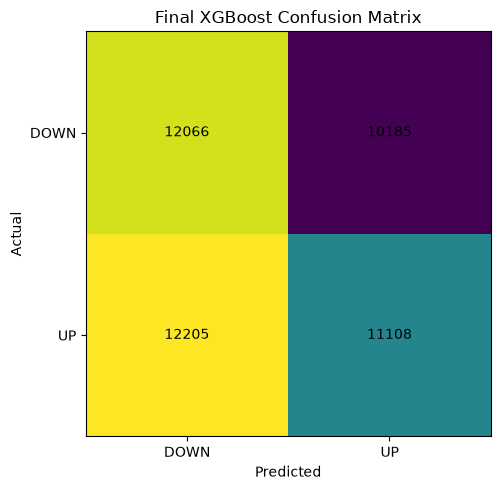

In [148]:
plt.figure(figsize=(6, 5))

plt.imshow(final_cm)

plt.title(
    "Final XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["DOWN", "UP"]
)

plt.yticks(
    [0, 1],
    ["DOWN", "UP"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            final_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [149]:
final_importance = pd.DataFrame({
    "Feature": final_features,
    "Importance": final_model.feature_importances_
})

final_importance = (
    final_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

final_importance.head(25)

,Feature,Importance
0,Market_Return,0.023952
1,Market_SMA_20,0.023229
2,Market_SMA_5,0.023148
3,Market_Momentum_20D,0.022742
4,Market_Momentum_5D,0.022735
5,Market_Return_Lag_1,0.022610
6,Market_Return_Lag_5,0.022411
7,Market_Breadth,0.021211
8,Market_Volatility,0.020729
9,Candle_Direction,0.014497


In [150]:
final_importance.to_csv(
    "../data/processed/final_feature_importance.csv",
    index=False
)

pd.DataFrame([
    final_test_results
]).to_csv(
    "../data/processed/final_test_results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [151]:
final_predictions_df = df_model.loc[
    test_mask,
    ["Date", "Ticker", "Target"]
].copy()

final_predictions_df["Prediction"] = (
    test_final_predictions
)

final_predictions_df.to_csv(
    "../data/processed/final_predictions.csv",
    index=False
)

print(
    final_predictions_df.head()
)

                            Date         Ticker  Target  Prediction
216320 2022-02-18 00:00:00+05:30    ADANIENT.NS       0           0
216321 2022-02-18 00:00:00+05:30  ADANIPORTS.NS       0           0
216322 2022-02-18 00:00:00+05:30  ASIANPAINT.NS       0           0
216323 2022-02-18 00:00:00+05:30    AXISBANK.NS       1           0
216324 2022-02-18 00:00:00+05:30  BAJAJ-AUTO.NS       0           0


In [152]:
import joblib

joblib.dump(
    final_model,
    "../models/final_xgboost_model.joblib"
)

print("Model saved.")

Model saved.


In [153]:
pd.DataFrame({
    "Feature": final_features
}).to_csv(
    "../models/final_features.csv",
    index=False
)

print(
    "Feature list saved."
)

Feature list saved.


In [154]:
feature_columns_market = feature_columns + market_features

print("Technical features:", len(feature_columns))
print("Market features:", len(market_features))
print("Final features:", len(feature_columns_market))

Technical features: 82
Market features: 9
Final features: 91


In [155]:
df_final = df.dropna(
    subset=feature_columns_market + ["Target"]
).copy()

df_final = df_final.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

print("Final rows:", len(df_final))
print("Final features:", len(feature_columns_market))

Final rows: 261884
Final features: 91


In [156]:
unique_dates = sorted(df_final["Date"].unique())

train_end = int(len(unique_dates) * 0.70)
val_end = int(len(unique_dates) * 0.85)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_df = df_final[df_final["Date"].isin(train_dates)]
val_df = df_final[df_final["Date"].isin(val_dates)]
test_df = df_final[df_final["Date"].isin(test_dates)]

print("Train:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Validation:", val_df["Date"].min(), "to", val_df["Date"].max())
print("Test:", test_df["Date"].min(), "to", test_df["Date"].max())

Train: 1999-05-14 00:00:00+05:30 to 2018-03-07 00:00:00+05:30
Validation: 2018-03-08 00:00:00+05:30 to 2022-02-14 00:00:00+05:30
Test: 2022-02-15 00:00:00+05:30 to 2026-01-30 00:00:00+05:30


In [157]:
X_train = train_df[feature_columns_market]
y_train = train_df["Target"]

X_val = val_df[feature_columns_market]
y_val = val_df["Target"]

X_test = test_df[feature_columns_market]
y_test = test_df["Target"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(170460, 91)
(45719, 91)
(45705, 91)


In [158]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Final model trained successfully.")

Final model trained successfully.


In [159]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

val_pred = final_model.predict(X_val)

val_results = {
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred),
    "Recall": recall_score(y_val, val_pred),
    "F1": f1_score(y_val, val_pred)
}

print(val_results)

{'Accuracy': 0.510772326603819, 'Precision': 0.5237422530076559, 'Recall': 0.49096501345636295, 'F1': 0.5068242453641435}


In [160]:
test_pred = final_model.predict(X_test)

test_results = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1": f1_score(y_test, test_pred)
}

print(test_results)

{'Accuracy': 0.504168034131933, 'Precision': 0.5157955969214247, 'Recall': 0.49328141047586443, 'F1': 0.5042873392247791}


In [161]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_pred,
    target_names=["DOWN", "UP"]
))

              precision    recall  f1-score   support

        DOWN       0.49      0.52      0.50     22337
          UP       0.52      0.49      0.50     23368

    accuracy                           0.50     45705
   macro avg       0.50      0.50      0.50     45705
weighted avg       0.50      0.50      0.50     45705



In [162]:
importance_df = pd.DataFrame({
    "Feature": feature_columns_market,
    "Importance": final_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(importance_df.head(20))

                Feature  Importance
82        Market_Return    0.023221
88        Market_SMA_20    0.022984
89  Market_Return_Lag_1    0.022704
84   Market_Momentum_5D    0.022578
85  Market_Momentum_20D    0.022408
90  Market_Return_Lag_5    0.022341
87         Market_SMA_5    0.022070
76      High_Volatility    0.021512
86       Market_Breadth    0.021116
83    Market_Volatility    0.020899
24       Price_vs_SMA20    0.014930
78   Trend_Strength_20D    0.014651
60      Rolling_Low_20D    0.013353
1             Return_5D    0.013309
66         RSI_Oversold    0.013291
53         Volume_SMA_5    0.013193
35          Close_Lag_3    0.013158
46     Distance_52W_Low    0.013104
5                SMA_10    0.012773
36         Return_Lag_1    0.012575


In [163]:
importance_df.to_csv(
    "../data/processed/final_feature_importance.csv",
    index=False
)

In [165]:
# Load Close price from raw stock data
raw_close = pd.read_csv(
    "../data/raw/nifty50_historical_data.csv",
    usecols=["Date", "Ticker", "Close"]
)

raw_close["Date"] = pd.to_datetime(raw_close["Date"])

# Create predictions dataframe
predictions_df = test_df[
    ["Date", "Ticker", "Target"]
].copy()

# Add actual Close price
predictions_df = predictions_df.merge(
    raw_close,
    on=["Date", "Ticker"],
    how="left"
)

# Add prediction
predictions_df["Predicted"] = test_pred

print(predictions_df.head())
print(predictions_df.shape)

                       Date         Ticker  Target        Close  Predicted
0 2022-02-15 00:00:00+05:30    ADANIENT.NS       0  1741.143066          1
1 2022-02-15 00:00:00+05:30  ADANIPORTS.NS       1   704.399414          1
2 2022-02-15 00:00:00+05:30  ASIANPAINT.NS       0  3143.958496          0
3 2022-02-15 00:00:00+05:30    AXISBANK.NS       1   793.636292          1
4 2022-02-15 00:00:00+05:30  BAJAJ-AUTO.NS       0  3247.231934          1
(45705, 5)


In [166]:
import joblib

joblib.dump(
    final_model,
    "../models/final_xgboost_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [167]:
pd.DataFrame({
    "Feature": feature_columns_market
}).to_csv(
    "../models/final_features.csv",
    index=False
)

print("Final feature list saved.")

Final feature list saved.
